# Grokking Demo Notebook

<b style="color: red">To use this notebook in Colab, go to Runtime > Change Runtime Type and select GPU as the hardware accelerator.</b>

# Setup

In [ ]:
!echo $HOSTNAME
!python --version
!nvidia-smi

g004
Python 3.12.5
Mon Jun 15 13:59:12 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 575.57.08              Driver Version: 575.57.08      CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-PCIE-40GB          Off |   00000000:CA:00.0 Off |                    0 |
| N/A   24C    P0             33W /  250W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+----------------------------

In [1]:
# General Libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import einops
from fancy_einsum import einsum
import os
import tqdm.auto as tqdm
import random
from pathlib import Path
import plotly.express as px
from torch.utils.data import DataLoader

from typing import List, Union, Optional
from functools import partial
import copy

import itertools
from transformers import AutoModelForCausalLM, AutoConfig, AutoTokenizer
import dataclasses
import datasets
from IPython.display import HTML

# CSV Use Libraries
import pandas as pd
import ast

# Function Imports 
from torch.optim.lr_scheduler import ReduceLROnPlateau
from transformers import get_cosine_schedule_with_warmup
from torch.nn.utils import clip_grad_norm_

ModuleNotFoundError: No module named 'torch'

### Save Directories
- Specify Notebook Directory 
- Specify Dataset Directory

In [3]:
oldDir = os.getcwd() # run once at initialization
print(oldDir)

/home/linrya/CoxeterArtinProject/transformer


In [40]:
# Change into the correct directory
#os.chdir(os.path.join(oldDir, "transformer-training-v2", "notebooks", "submittedNotebook"))
#os.chdir(os.path.join(oldDir, "transformer-training-v2", "runs", "oldControlRun"))


# Specify path of the Datasets directory
#DATA_PATH = Path(os.path.join(oldDir, "transformer-training-v2", "datasets", "A2 Large V1"))
#DATA_PATH = Path(os.path.join(oldDir, "transformer-training-v2", "datasets", "A2 Old"))
DATA_PATH = Path(oldDir)

# Print Saved Paths
print(f"New Dir : {os.getcwd()}")
print(f"Data Dir: {DATA_PATH}")

New Dir : /home/linrya/CoxeterArtinProject/transformer
Data Dir: /home/linrya/CoxeterArtinProject/transformer


In [23]:
# GPU Memory Setup

# Limit GPU usage to 90% of total memory
torch.cuda.set_per_process_memory_fraction(0.9, device=0)

# Prevent fragmentation
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:128,expandable_segments:True"

# Clear leftover memory
torch.cuda.empty_cache()

print("Allocated memory:", torch.cuda.memory_allocated() / 1024**3, "GB")
print("Cached memory:   ", torch.cuda.memory_reserved() / 1024**3, "GB")

Allocated memory: 0.0014996528625488281 GB
Cached memory:    0.001953125 GB


## Define Graphing Functs

In [24]:
# Plotly needs a different renderer for VSCode/Notebooks vs Colab argh
import plotly.io as pio
pio.renderers.default = "notebook_connected"
print(f"Using renderer: {pio.renderers.default}")

Using renderer: notebook_connected


In [25]:
pio.templates['plotly'].layout.xaxis.title.font.size = 20
pio.templates['plotly'].layout.yaxis.title.font.size = 20
pio.templates['plotly'].layout.title.font.size = 30

In [26]:
import transformer_lens
import transformer_lens.utils as utils
from transformer_lens.hook_points import (
    HookedRootModule,
    HookPoint,
)  # Hooking utilities
from transformer_lens import HookedTransformer, HookedTransformerConfig, FactoredMatrix, ActivationCache

Plotting helper functions:

In [27]:
def imshow(tensor, renderer=None, xaxis="", yaxis="", **kwargs):
    px.imshow(utils.to_numpy(tensor), color_continuous_midpoint=0.0, color_continuous_scale="RdBu", labels={"x":xaxis, "y":yaxis}, **kwargs).show(renderer)

def line(tensor, renderer=None, xaxis="", yaxis="", **kwargs):
    px.line(utils.to_numpy(tensor), labels={"x":xaxis, "y":yaxis}, **kwargs).show(renderer)

def scatter(x, y, xaxis="", yaxis="", caxis="", renderer=None, **kwargs):
    x = utils.to_numpy(x)
    y = utils.to_numpy(y)
    px.scatter(y=y, x=x, labels={"x":xaxis, "y":yaxis, "color":caxis}, **kwargs).show(renderer)

## Set Paths and GPU Devices

In [28]:
# Define the location to save the model, using a relative path
PTH_LOCATION = "workspace/_scratch/model.pth"

# Create the directory if it does not exist
os.makedirs(Path(PTH_LOCATION).parent, exist_ok=True)

In [29]:
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Device count: {torch.cuda.device_count()}")

for i in range(torch.cuda.device_count()):
    print(f"Device {i}: {torch.cuda.get_device_name(i)}")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device Name: {device}")

# setting up specific devices
device1 = None 
if torch.cuda.is_available():       #torch.cuda.device_count() and make a devices list maybe? (only using 1 right now)
    device1 = torch.device("cuda:0")

# CLI commands
print("CLI Commands:")
!CUDA_LAUNCH_BLOCKING=1         # enables cuda launch blocking
!echo $CUDA_VISIBLE_DEVICES
!nvidia-smi

CUDA available: True
Device count: 1
Device 0: NVIDIA A100-PCIE-40GB
Device Name: cuda
CLI Commands:
0
Mon Jun 15 14:00:51 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 575.57.08              Driver Version: 575.57.08      CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-PCIE-40GB          Off |   00000000:CA:00.0 Off |                    0 |
| N/A   25C    P0             35W /  250W |     425MiB /  40960MiB |      0%      Default |
|                                    

## Define Model and Optimizer Params

**Task:** Coxeter Group input and Binary Classification Output

- define each generator as a token and embbed it
- embbed word using generator embeddingsa

- `[B,T,C]` 
    - Batch Size | dataset size fed into model
    - Sequence Length | ctx 
    - Number of Features | d_model

- Sequence (an input):
    - sequence: `[1,2,3,4]`
    - the label: `0` or `1`
    - each token has a `d_model` lengthed "features" vector

**import training data as train_data, its label as train_labels
testing data as test_data, its label as test_labels**

In [30]:
# --- Defining Boolean Modes ---
TRAIN_MODEL = True
# if false, then it will load the pretrained model

In [ ]:
# Set Randomization
DATA_SEED = 598
LENS_SEED = 999
torch.manual_seed(seed=DATA_SEED)
torch.cuda.manual_seed_all(DATA_SEED)
# optional (more restrictive) (also for cudnn which isn't being used)
#torch.backends.cudnn.deterministic = True
#torch.backends.cudnn.benchmark = False


# Train/Test Split (unused)
frac_train = 0.4 

# --- Training Loop Config ---
num_epochs = 25000 #can be changed for our dataset
checkpoint_every = 100

# --- Transformer Config ---
cfg = HookedTransformerConfig(
    n_ctx= 22,              # fixed sequence length (size of an input)
    n_layers = 1,
    n_heads = 4,
    d_head = 64,
    d_model = 256,          # nHeads * dHeads
    d_mlp = 256,            # d_model * 4 (recommended)
    d_vocab= 6,             # token types = numOfGens + 1Padding + 1 mask?
    d_vocab_out=6,          # 
    act_fn = "relu",        # break's linearization
    init_weights=True,
    device=device,          # "cuda"
    n_devices=1,
    seed = LENS_SEED,
    attention_dir = "causal",        # bidirectional/causal
    normalization_type=None,                # None, LN, LNPre, RMS, RMSPre (use LN for others)
)
cached_data = None
if not TRAIN_MODEL:
    cached_data = torch.load(PTH_LOCATION, weights_only=False)    
    cfg = cached_data["config"]    

# --- Optimizer Config --- 
# NOTE: a small learning rate (lr) is recommended for more complex models to avoid massive jumps, a schdeuler is likely necessary for >1 transformer layer
lr = 1e-5
wd = 7      
betas = (0.9, 0.98)
patience = 20

# --- Schedueler Config --- 
warmup_steps = (int) (num_epochs * 0.1)

In [32]:
# --- Load Model and Optimizer ---
model = HookedTransformer(cfg)
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd, betas=betas)


scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=20, factor=0.5)

# NOTE just the initialization of this alternative warmup scheduler results in 50/50 after 100 epochs accuracy, only do scheduler with minibatches and don't initialize until then
#scheduler = get_cosine_schedule_with_warmup(
#    optimizer, 
#    num_warmup_steps=warmup_steps,
#    num_training_steps=num_epochs
#)

In [33]:
# -- Update State Dicts (if using Pretrained model) ---
if not TRAIN_MODEL:
    model.load_state_dict(cached_data["model"])
    optimizer.load_state_dict(cached_data["optimizer"])
    scheduler.load_state_dict(cached_data["scheduler"])

In [34]:
# NOTE: Disabling the biases, because it makes things easier to interpret.
for name, param in model.named_parameters():
    if "b_" in name:
        param.requires_grad = False

## Define Loss and Accuracy Functions [change it to cross entropy loss??]

In [ ]:
import torch.nn.functional as F

def autoregressive_loss_fn(logits, tokens):
    """
    logits: shape [batch, seq_len, vocab_size]
    tokens: shape [batch, seq_len] (The original token strings)
    """
    # 1. Shift logits and targets so they align: input at t predicts token at t+1
    shift_logits = logits[:, :-1, :].contiguous()
    shift_labels = tokens[:, 1:].contiguous()
    
    # 2. Flatten the dimensions so PyTorch's cross_entropy can read them
    # New shapes: [batch * (seq_len - 1), vocab_size] and [batch * (seq_len - 1)]
    flat_logits = shift_logits.view(-1, shift_logits.size(-1))
    flat_labels = shift_labels.view(-1)
    
    # 3. Compute standard cross entropy loss across all substrings
    loss = F.cross_entropy(flat_logits, flat_labels)
    return loss

def autoregressive_accuracy_fn(logits, tokens):
    """
    Calculates percentage of correct next-token predictions across all substrings
    """
    shift_logits = logits[:, :-1, :].contiguous()
    shift_labels = tokens[:, 1:].contiguous()
    
    flat_logits = shift_logits.view(-1, shift_logits.size(-1))
    flat_labels = shift_labels.view(-1)
    
    # Get the token ID with the highest probability prediction
    predictions = torch.argmax(flat_logits, dim=-1)
    
    correct = (predictions == flat_labels).float()
    return correct.mean()

## Define Attention Masking Functions

In [36]:
# Create attention mask: 1 for real tokens, 0 for padding
def create_attention_mask(data_tensor):
    # assuming padding is exactly 0
    return (data_tensor != 0).int()

def pad_mask_hook(attn_scores, hook, mask):
    # attn_scores: [batch, head, q_pos, k_pos]
    # mask: [batch, seq_len]
    # Mask padding tokens from being attended to
    # Set attention scores to -inf where key is padding
    pad_mask = mask.unsqueeze(1).unsqueeze(2)  # [batch, 1, 1, seq_len]
    attn_scores = attn_scores.masked_fill(~pad_mask.bool(), float('-inf'))
    return attn_scores

def register_pad_mask_hook(model, attention_mask):
    def mask_hook(attn_scores, hook):
        return pad_mask_hook(attn_scores, hook, attention_mask)

    for layer in range(cfg.n_layers):
        model.blocks[layer].attn.hook_attn_scores.add_hook(mask_hook)


## Initialize Datasets

### Loading Test

In [ ]:
# Initialize functions for getting and saving csv dataframes (Interleaved Data)

# return tensor representing the dataset
def load_dataset_from_csv(file_path):
    # Load the CSV file, reading only the single combined column 'tokens'
    df = pd.read_csv(file_path, names=['tokens'], skiprows=1)
    df['tokens'] = df['tokens'].apply(lambda x: [int(i.strip(" '")) for i in x.strip("[]").split(",")])
    
    words = [torch.tensor(seq) for seq in df['tokens']]
    # Strategy B treats the sequence as its own label, returning just one stacked matrix
    return torch.stack(words) 

def write_dataset_to_csv(file_path, data):
    data_list = data.tolist()
    formatted_tokens = [str([str(token) for token in seq]) for seq in data_list]
    df = pd.DataFrame({'tokens': formatted_tokens})
    df.to_csv(file_path, index=False, header=True)

In [42]:
reservedFiles = {
    "test": "test.csv",
    "train": "train.csv",
    "relators": "relators.csv"
}
reservedFilesL = list(reservedFiles.values())

# Load test set as usual
test_data, test_labels = load_dataset_from_csv(DATA_PATH / reservedFiles["test"])

### Load Train

- first make the datasets dictionary

In [43]:
USE_TRAIN_CSV = True

if not USE_TRAIN_CSV: 
    # Initialize datasets dictionary
    datasets = {}

    # get relators (train) first and save separately (added to datasets later)
    relators_data, relators_labels = load_dataset_from_csv(DATA_PATH / reservedFiles["relators"])

    # Scan current directory for all .csv files except for the reserved ones (this will represent the )
    fileNames = []
    for file in os.listdir(DATA_PATH):
        if file.endswith(".csv") and file not in reservedFilesL:
            fileNames.append(file)
    fileNames = sorted(fileNames, key=lambda name: int(name.split('-')[0]))

    # add relators into datasets dict, and all n-train csv's 
    datasets["relators"] = load_dataset_from_csv(DATA_PATH / "relators.csv")
    for fileName in fileNames:
        dataset_name = fileName.replace(".csv", "")  # e.g., "6-words" or "relators"
        data, labels = load_dataset_from_csv(DATA_PATH / fileName)
        datasets[dataset_name] = (data, labels)

    # Optional sanity check
    print("Loaded datasets:")
    for name in datasets:
        print(f"  {name}: {datasets[name][0].shape} words, {datasets[name][1].shape} labels")

In [ ]:
wordIndex = 0 
chosenWord = train_data[wordIndex].unsqueeze(0).to(device)

with torch.inference_mode():
    model.reset_hooks()
    mask = create_attention_mask(chosenWord).to(device)
    register_pad_mask_hook(model, mask)
    logits, cache = model.run_with_cache(chosenWord)

# Generate beautiful step-by-step token labels
str_tokens = [f"{i}:s_{tok}" for i, tok in enumerate(chosenWord[0].tolist())]

for layer in range(model.cfg.n_layers):
    for head in range(model.cfg.n_heads):
        # Extract the full 22x22 square matrix grid
        attn_single_head = cache["pattern", layer][0, head].detach().cpu()
        
        imshow(
            attn_single_head,
            xlabels=str_tokens,
            ylabels=str_tokens,
            xaxis="Key (Attended To)",
            yaxis="Query (Paying Attention)",
            title=f"Layer {layer} Head {head} Full Causal Attention Map"
        )

In [ ]:
if not USE_TRAIN_CSV:
    # Create aggregated training data from all datasets
    all_data_list = []
    all_labels_list = []

    # This will loop in order of: relators, and then up n lengths in proper numeric order
    for name, (data, labels) in datasets.items():
        all_data_list.append(data)
        all_labels_list.append(labels)

    # -- First Concat all Train Files ---
    train_data = torch.cat(all_data_list, dim=0)
    train_labels = torch.cat(all_labels_list, dim=0)

# Load test set as a single fused tensor
test_data = load_dataset_from_csv(DATA_PATH / reservedFiles["test"])

if USE_TRAIN_CSV:
    # Load training set as a single fused tensor
    train_data = load_dataset_from_csv(DATA_PATH / "train.csv")

# --- Then Shuffle Their order ---
tPerm = torch.randperm(train_data.size(0))       
originalTrainDex = torch.argsort(tPerm)          

# --- Save Ordered Data into CSV ---
write_dataset_to_csv(DATA_PATH / reservedFiles["train"], train_data)

# --- Reassign Data to permuted form ---
train_data = train_data[tPerm].to(device1)
test_data = test_data.to(device1)

# --- Create Attention Masks ---
test_attention_mask = create_attention_mask(test_data).to(device1)
train_attention_mask = create_attention_mask(train_data).to(device1)

In [ ]:
# Debug: Verify that the shape of the train dataset makes sense
print(f"Batch Size: {train_data.shape[0]} | Seq Len: {train_data.shape[1]}")     # [B,T] [Total inputs, Input length] [Batch Size, Token Length, ]

Batch Size: 51720 | Seq Len: 22


## Initialize Lists for Training Session

- add masking + move to proper device

In [ ]:
# Initialize Test
test_data = test_data.to(device1)
test_labels = test_labels.to(device1)

# --- Create Attention Masks ---
test_attention_mask = create_attention_mask(test_data).to(device1)
train_attention_mask = create_attention_mask(train_data).to(device1)

# NOTE: move subdatasets only if doing alternating training (typically not done)
# Moves all datasets into gpu "device1"
ALTERNATE_TRAINING = False
if not USE_TRAIN_CSV and ALTERNATE_TRAINING:
    for name in datasets:
        data, labels = datasets[name]
        data = data.to(device1)
        labels = labels.to(device1)
        datasets[name] = (data, labels)


# checkpoint lists
model_checkpoints = []
checkpoint_epochs = []

# performance metric lists
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

In [ ]:
!nvidia-smi

Mon Jun 15 14:03:19 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 575.57.08              Driver Version: 575.57.08      CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-PCIE-40GB          Off |   00000000:CA:00.0 Off |                    0 |
| N/A   25C    P0             35W /  250W |     537MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

# Training

In [ ]:
#num_epochs = 100   # num_epochs    (debug, keep commented out)

# --- Locate this block in your training loop cell ---
if TRAIN_MODEL:
    for epoch in tqdm.tqdm(range(num_epochs)):
        # ---- Register hook for train ----
        model.reset_hooks()
        register_pad_mask_hook(model, train_attention_mask)

        # =========================================================
        # STRATEGY B: Pass train_data cleanly into the model 
        # =========================================================
        train_logits = model(train_data) 
        
        # Pass train_data to the loss function twice (logits first, then target tokens)
        train_loss = autoregressive_loss_fn(train_logits, train_data) 
        train_loss.backward()
        train_losses.append(train_loss.item())

        # ---- Accuracy (train) ----
        train_accuracy = autoregressive_accuracy_fn(train_logits, train_data)
        train_accuracies.append(train_accuracy)

        # ---- Optimizer + Scheduler step ----
        optimizer.step()
        optimizer.zero_grad()
        
        # ---- Evaluation ----
        with torch.inference_mode():
            model.reset_hooks()
            register_pad_mask_hook(model, test_attention_mask)

            # =========================================================
            # ALSO INSERTED HERE: Apply the same slicing to test data
            # =========================================================
            test_inputs = test_data[:, :-1]
            # =========================================================

            # ---- Forward pass (test) ----
            test_logits = model(test_inputs) # Pass test_inputs here
            test_loss = autoregressive_loss_fn(test_logits, test_data)
            test_losses.append(test_loss.item())

            # ---- Accuracy (test) ----
            test_accuracy = autoregressive_accuracy_fn(test_logits, test_data)
            test_accuracies.append(test_accuracy)

        # ---- Checkpoint ----
        if ((epoch + 1) % checkpoint_every) == 0:
            checkpoint_epochs.append(epoch)
            # Save model’s weights (not model)
            model_checkpoints.append(copy.deepcopy(model.state_dict()))
            print(
                f"Epoch {epoch} | "
                f"Train Loss: {train_loss.item():.4f} | "
                f"Test Loss: {test_loss.item():.4f} | "
                f"Train Acc: {train_accuracy:.4f} | "
                f"Test Acc: {test_accuracy:.4f}"
            )


  0%|          | 0/25000 [00:00<?, ?it/s]

Epoch 99 | Train Loss: 0.6930 | Test Loss: 0.6931 | Train Acc: 0.5109 | Test Acc: 0.5104
Epoch 199 | Train Loss: 0.6929 | Test Loss: 0.6931 | Train Acc: 0.5152 | Test Acc: 0.5106
Epoch 299 | Train Loss: 0.6928 | Test Loss: 0.6929 | Train Acc: 0.5157 | Test Acc: 0.5104
Epoch 399 | Train Loss: 0.6924 | Test Loss: 0.6926 | Train Acc: 0.5149 | Test Acc: 0.5114
Epoch 499 | Train Loss: 0.6919 | Test Loss: 0.6921 | Train Acc: 0.5252 | Test Acc: 0.5219
Epoch 599 | Train Loss: 0.6910 | Test Loss: 0.6911 | Train Acc: 0.5376 | Test Acc: 0.5335
Epoch 699 | Train Loss: 0.6897 | Test Loss: 0.6898 | Train Acc: 0.5479 | Test Acc: 0.5448


**Weird Decision:** Training the model with full batch training rather than stochastic gradient descent. We do this so to make training smoother and reduce the number of slingshots.

# Save or Load Model

In [ ]:
if TRAIN_MODEL:
    torch.save(
        {
            "config": model.cfg,
            "model":model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "scheduler": scheduler.state_dict(),
            "checkpoints": model_checkpoints,
            "checkpoint_epochs": checkpoint_epochs,
            "test_losses": test_losses,
            "train_losses": train_losses,
            "train_accuracies": train_accuracies,
            "test_accuracies": test_accuracies,
        },
        PTH_LOCATION)

In [ ]:
if not TRAIN_MODEL:
    cached_data = torch.load(PTH_LOCATION, weights_only=False)
    model.load_state_dict(cached_data['model'])
    optimizer.load_state_dict(cached_data["optimizer"])
    scheduler.load_state_dict(cached_data["scheduler"])
    model_checkpoints = cached_data["checkpoints"]
    checkpoint_epochs = cached_data["checkpoint_epochs"]
    test_losses = cached_data['test_losses']
    train_losses = cached_data['train_losses']
    train_accuracies = cached_data["train_accuracies"]
    test_accuracies = cached_data["test_accuracies"]

# Graph Results

In [ ]:
from neel_plotly.plot import line_or_scatter, line

In [ ]:
skipBy = 100
def createGraph(yTrain, yTest, yName, title):
    line = partial(line_or_scatter, plot_type="line", return_fig=True)
    fig = line(
        [yTrain[::skipBy], yTest[::skipBy]],
        x=np.arange(0, len(yTrain), skipBy),
        xaxis="Epoch",
        yaxis=yName,
        log_y=True,
        title=title,
        line_labels=['train', 'test'],
        toggle_x=True,
        toggle_y=True        
    )
    return fig

fig1 = createGraph(train_losses, test_losses, "Loss", "Loss Curve for Word Problem")
fig2 = createGraph(train_accuracies, test_accuracies, "Accuracy", "Accuracy Curve for Word Problem")

# display graphs
fig1.show()
fig2.show()

# save graphs
fig1.write_html("loss_curve.html")
fig2.write_html("accuracy_curve.html")

# Analysing the Model

Helpful Memory Probing Functions:

- nvidia-smi
- torch.cuda.empty_cache()
- torch.set_grad_enabled(mode=False)
- gc.collect()
- print(torch.cuda.memory_summary())
- torch profiler also (saved image on Aug 03, 2025 ~6pm)

### Helper Functions
- logit return function
- prediction function

In [ ]:
import gc

def getLogits(model:HookedTransformer, data, getCache:bool=False): 
    """
    auto creates and applies mask to get logits using model
    saves lots of memory be detaching logits from model graph
    """
    with torch.inference_mode():
        model.reset_hooks()
        mask = create_attention_mask(data).to(device1)
        register_pad_mask_hook(model, mask)
        if getCache:
            original_logits_og, cache = model.run_with_cache(data)
        else:
            original_logits_og = model(data)
    # free memory
    original_logits = original_logits_og.detach().clone()
    del original_logits_og, mask
    torch.cuda.empty_cache()
    if getCache:
        return original_logits, cache
    else:
        return original_logits

def getPredictions(model:HookedTransformer, data): 
    logits = getLogits(model, data, getCache=False)
    if len(logits.shape) == 3:          #IMPORTANT
        logits = logits[:, clsDex]
    preds = logits.argmax(dim=-1)
    del logits
    return preds


# --- Update imshow function from earlier ---
def imshow(tensor, renderer=None, xaxis="", yaxis="", xlabels=None, ylabels=None, aspect="auto", **kwargs):
    fig = px.imshow(
        utils.to_numpy(tensor), 
        color_continuous_midpoint=0.0, 
        color_continuous_scale="RdBu", 
        labels={"x": xaxis, "y": yaxis},
        aspect=aspect,
        **kwargs
    )
    
    if xlabels is not None:
        fig.update_xaxes(
            tickmode='array',
            tickvals=list(range(len(xlabels))),
            ticktext=xlabels,
        )
    if ylabels is not None:
        fig.update_yaxes(
            tickmode='array',
            tickvals=list(range(len(ylabels))),
            ticktext=ylabels
        )
        
    
    # Optional: remove fixed aspect ratio locking to let heatmap stretch
    fig.update_yaxes(scaleanchor=None)
    
    fig.show(renderer)
    return fig

def cleanup():
    gc.collect()
    torch.cuda.empty_cache()

## Quick Analysis + Memory Cleanup

In [ ]:
!nvidia-smi
# disable gradient tracking for backpropagation (with inference mode default on) # note: transformer lens does lots of caching stil 
torch.set_grad_enabled(False)
gc.collect()
torch.cuda.empty_cache()

Thu Aug  7 14:57:45 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 575.57.08              Driver Version: 575.57.08      CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L40S                    Off |   00000000:E1:00.0 Off |                  Off |
| N/A   31C    P0             82W /  350W |    3311MiB /  49140MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
original_logits, cache = getLogits(model, train_data, getCache=True)
!nvidia-smi

Thu Aug  7 14:57:46 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 575.57.08              Driver Version: 575.57.08      CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L40S                    Off |   00000000:E1:00.0 Off |                  Off |
| N/A   32C    P0            126W /  350W |   17907MiB /  49140MiB |      9%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

Get key weight matrices:

In [ ]:
W_E = model.embed.W_E[:-1]
print("W_E", W_E.shape)
W_neur = W_E @ model.blocks[0].attn.W_V @ model.blocks[0].attn.W_O @ model.blocks[0].mlp.W_in
print("W_neur", W_neur.shape)
W_logit = model.blocks[0].mlp.W_out @ model.unembed.W_U
print("W_logit", W_logit.shape)

W_E torch.Size([3, 256])
W_neur torch.Size([4, 3, 256])
W_logit torch.Size([256, 2])


In [ ]:
original_loss = loss_fn(original_logits, train_labels).item()
print("Original Loss:", original_loss)

Original Loss: 2.8368760604233936


### Looking at Activations

Get all shapes:

In [ ]:
for param_name, param in cache.items():
    print(param_name, param.shape)

hook_embed torch.Size([51720, 22, 256])
hook_pos_embed torch.Size([51720, 22, 256])
blocks.0.hook_resid_pre torch.Size([51720, 22, 256])
blocks.0.attn.hook_q torch.Size([51720, 22, 4, 64])
blocks.0.attn.hook_k torch.Size([51720, 22, 4, 64])
blocks.0.attn.hook_v torch.Size([51720, 22, 4, 64])
blocks.0.attn.hook_attn_scores torch.Size([51720, 4, 22, 22])
blocks.0.attn.hook_pattern torch.Size([51720, 4, 22, 22])
blocks.0.attn.hook_z torch.Size([51720, 22, 4, 64])
blocks.0.hook_attn_out torch.Size([51720, 22, 256])
blocks.0.hook_resid_mid torch.Size([51720, 22, 256])
blocks.0.mlp.hook_pre torch.Size([51720, 22, 256])
blocks.0.mlp.hook_post torch.Size([51720, 22, 256])
blocks.0.hook_mlp_out torch.Size([51720, 22, 256])
blocks.0.hook_resid_post torch.Size([51720, 22, 256])


In [ ]:
# debug: prints the first 4 input train data values
train_data[:4]
print(model.W_E.shape)

torch.Size([4, 256])


## Attention Heads (average)

### Average attention over all words for each head
Note: all train data input words used and averaged out for these graphs
- x: letters (keys attended to)
- y: letters (query giving attention to x axis)


In [ ]:
n_heads = model.cfg.n_heads
seq_len = model.cfg.n_ctx

head_sums = None
num_samples = 0

with torch.inference_mode():
    for layer in range(model.cfg.n_layers):
        for wordIndex in range(len(train_data)):
            # Grab attention pattern: [n_heads, seq_len, seq_len]
            attn_patterns = cache["pattern", 0][wordIndex] # Remove batch dim (specify word)

            # Initialize head_sums on the correct device
            if head_sums is None:
                head_sums = torch.zeros_like(attn_patterns)

            # Accumulate
            head_sums += attn_patterns
            num_samples += 1

        # Average attention
        avg_attn = head_sums / num_samples

        # Create labels
        str_tokens = [str(i) for i in range(seq_len)]

        # Plot each head

        for head in range(n_heads):
            imshow(
                avg_attn[head].detach().cpu(),
                x=str_tokens,
                y=str_tokens,
                xaxis="Key (Attended To)",
                yaxis="Query (Paying Attention)",
                title=f"Layer {layer} Head {head} — Average Attention Across Dataset",
                aspect=None,
            )


### Average Attention Pattern over Attention Heads

In [ ]:
# Average Attention Pattern over Attention Heads
for layer in range(model.cfg.n_layers):
    attention = cache["pattern", layer].mean(dim=0)[:, clsDex, :]
    imshow(
        attention,
        title=f"Average Attention Paid | for token {clsDex} | per head | layer {layer}",
        xaxis="Source",
        yaxis="Head",
        x=[str(i) for i in range(train_data.shape[1])],
        ylabels=[f"{i}" for i in range(attention.shape[0])]

    )

##  Attention Heads (word: X)

In [ ]:
# Look at specific word in the dataset
# NOTE subtract 2 from the word index in the csv

#originalTrainDex[ogIndex] | train_data[newIndex] 
wordIndex = 5 #2066
wordIndex = originalTrainDex[wordIndex]

# --- Debug Print Word --- 
print(f"Word: {train_data[wordIndex].tolist()}")

Word: [2, 1, 3, 1, 2, 1, 2, 3, 2, 3, 2, 1, 3, 1, 2, 3, 2, 1, 3, 2, 0, 0]


In [ ]:
# Prediction (evaluating model)

# --- get specific word and it's label ---
wordTensor = train_data[wordIndex]
wordLabel = train_labels[wordIndex]
wordTensorFit = wordTensor.unsqueeze(0)     # get into batch ready size
pred = getPredictions(model, wordTensorFit)

# --- print results ---
print(f"Word: {wordTensor.tolist()}")
print(f"Label: {wordLabel}")
print(f"Pred : {pred.item()}")      #1st and only scalar value in pred tensor

Word: [2, 1, 3, 1, 2, 1, 2, 3, 2, 3, 2, 1, 3, 1, 2, 3, 2, 1, 3, 2, 0, 0]
Label: 0
Pred : 1


### Attention patterns per each head on ONE word
- prints 4 graphs

In [ ]:
# Prints 1 graph per attention head
# x: letters (keys attended to)
# y: letters (query giving attention to x axis)


# Move to test device, because it has more memory
chosenWord = train_data[wordIndex].unsqueeze(0).to(device1)  # shape (1, 22)
print(chosenWord)


# Generate labeled tokens with position

# ex: word len 22: str_tokens = [0,...,21]
str_tokens = [f"{i}" for i, tok in enumerate(chosenWord[0])]

# Visualize
n_heads = model.cfg.n_heads
n_layers = model.cfg.n_layers
for layer in range(n_layers):
    for head in range(n_heads):
        # gets the attention pattern for layer 0, pick 1 word from the batch and look at 1 head for it
        # detatch tensor from computation graph (no gradients), move tensor to cpu to make imshow heatmap
        attn_single_head = cache["pattern", layer][wordIndex, head].detach().cpu()
        imshow(
            attn_single_head,
            x=str_tokens,
            y=str_tokens,
            xaxis="Key (Attended To)",
            yaxis="Query (Paying Attention)",
            title=f"Layer {layer} Head {head} Attention Pattern (Positional Tokens)",
            aspect=None
        )


tensor([[2, 1, 3, 1, 2, 1, 2, 3, 2, 3, 2, 1, 3, 1, 2, 3, 2, 1, 3, 2, 0, 0]],
       device='cuda:0')


### Attention Pattern for wordIndex over attention Heads

In [ ]:
# Attention pattern for a specific word (x: generators, y: attention heads)
# Assuming train_data is shape (batch, seq_len), and you're using batch 0?

token_strs = [str(x) for x in chosenWord.squeeze(0).tolist()]

for layer in range(model.cfg.n_layers):
    attention = cache["pattern", layer][wordIndex][:, clsDex, :]
    imshow(
        attention,
        title=f"Attention Pattern (for word {wordIndex}) over Attention Heads in layer {layer}",
        xaxis="Source",
        yaxis="Head",
        #x=[str(i) for i in range(train_data.shape[1])],
        xlabels=token_strs,
        ylabels=[f"{i}" for i in range(attention.shape[0])]
    )

print([str(i) for i in range(train_data.shape[1])])
print(token_strs)

['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21']
['2', '1', '3', '1', '2', '1', '2', '3', '2', '3', '2', '1', '3', '1', '2', '3', '2', '1', '3', '2', '0', '0']


## Misclassification Graphs
- Experimenting with looking at length of consistently incorrect words
- TODO: reanalyze this code to make it more efficient

### Train Misclassification Graphs:

In [ ]:
# Train misclassification
import matplotlib.pyplot as plt
import random
from collections import defaultdict

# Lists to store stats
words = []
wrongs = []
lengths = []
correct_labels = []
dataset_indices = []

# For tracking counts by length
total_by_length = defaultdict(int)
misclassified_by_length = defaultdict(int)

# --- Get ALL predictions given batch of data ---
train_preds = getPredictions(model, train_data)
correct_mask = (train_preds == train_labels)


# --- Fill up the missclasification metric lists ---

for i in range(len(train_preds)):
    input_seq = train_data[i].tolist()
    true_label = train_labels[i].item()
    pred_label = train_preds[i].item()
    
    # Convert to string representation
    word_str = ' '.join([str(int(tok)) for tok in input_seq])
    word_len = sum(1 for ch in word_str.split(" ") if ch != "0" and ch.strip() != "")
    word_len = word_len - 1     # NOTE SUBTRACT SPECIAL TOKEN

    words.append(word_str)
    lengths.append(word_len)
    correct_labels.append(int(train_labels[i]))
    dataset_indices.append(i)
    
    total_by_length[word_len] += 1
    if not correct_mask[i]:
        wrongs.append(1)
        misclassified_by_length[word_len] += 1
    else: 
        wrongs.append(0)

# NOTE: wrongs is like the reverse of correct_mask

In [ ]:
# Debug
print(misclassified_by_length)

defaultdict(<class 'int'>, {21: 17900, 19: 6006, 17: 1733, 15: 467, 13: 143, 9: 14, 5: 2, 11: 40, 7: 2})



Random Sample of Misclassified Words:
Word: 1 3 2 3 2 3 2 1 2 3 2 3 2 3 1 2 3 2 3 2 3 1 | Length: 21 | Label: 0 | Dataset Index: 50342
Word: 3 1 2 1 2 3 2 3 1 2 1 2 1 3 1 2 3 1 3 1 0 0 | Length: 19 | Label: 0 | Dataset Index: 43828
Word: 2 3 1 2 1 3 2 3 2 1 2 1 3 2 3 2 3 2 3 2 3 1 | Length: 21 | Label: 1 | Dataset Index: 5147
Word: 1 2 3 2 1 2 1 2 3 2 3 2 3 2 1 3 1 2 1 2 0 0 | Length: 19 | Label: 0 | Dataset Index: 36701
Word: 1 2 1 2 3 1 2 3 2 3 2 3 1 3 1 2 3 1 3 1 3 1 | Length: 21 | Label: 0 | Dataset Index: 37088
Word: 2 1 3 2 1 2 3 2 3 2 1 2 1 3 2 3 2 3 1 2 0 0 | Length: 19 | Label: 1 | Dataset Index: 34523
Word: 1 2 1 3 1 3 2 1 2 1 2 1 3 2 1 2 3 2 3 1 2 1 | Length: 21 | Label: 1 | Dataset Index: 31664
Word: 3 1 3 1 2 3 2 3 2 3 2 3 1 2 1 2 1 3 1 2 1 2 | Length: 21 | Label: 0 | Dataset Index: 31213
Word: 3 1 2 1 3 1 3 1 2 1 2 3 2 3 2 3 1 3 2 3 1 3 | Length: 21 | Label: 0 | Dataset Index: 8531
Word: 2 3 1 3 1 3 2 3 2 3 2 1 2 1 2 1 2 1 2 1 2 1 | Length: 21 | Label: 1 | Dataset Index:

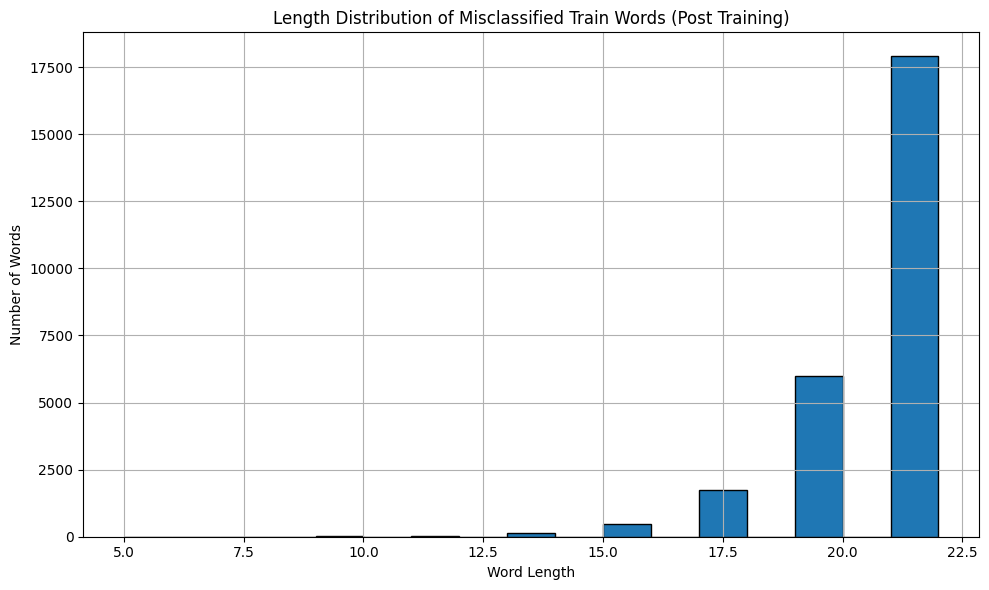

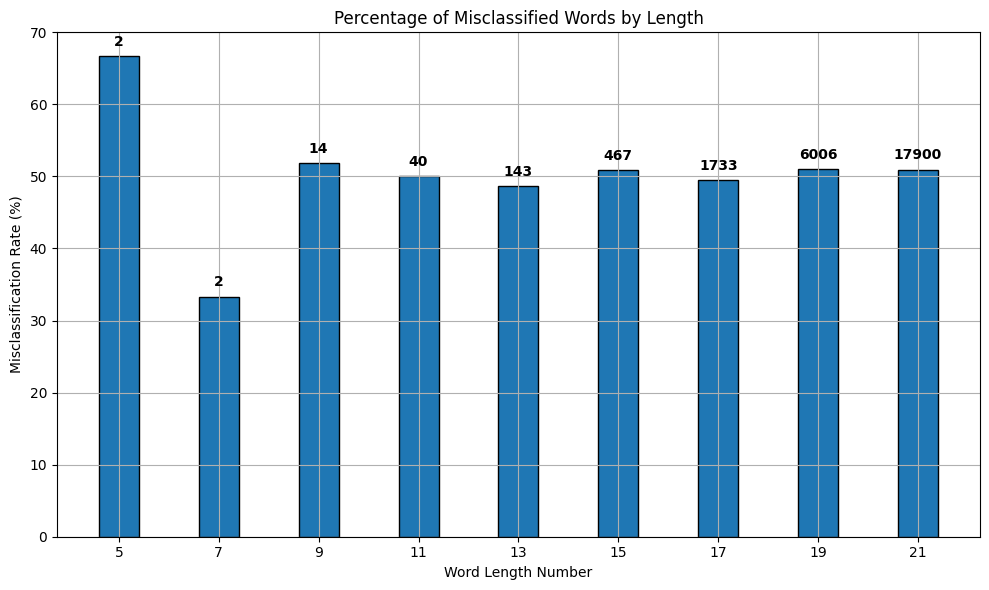

In [ ]:
# Collect misclassified words
misclassified = [
    (words[i], lengths[i], correct_labels[i], dataset_indices[i])
    for i in range(len(words)) if wrongs[i] > 0
]

# Random sample and print
print("\nRandom Sample of Misclassified Words:")
for word, length, label, idx in random.sample(misclassified, min(20, len(misclassified))):
    print(f"Word: {word} | Length: {length} | Label: {label} | Dataset Index: {idx}")

# Plot 1: Raw misclassified length distribution
misclassified_lengths = [length for _, length, _, _ in misclassified]
plt.figure(figsize=(10, 6))
plt.hist(misclassified_lengths, bins=range(min(misclassified_lengths), max(misclassified_lengths)+2), edgecolor='black')
plt.title("Length Distribution of Misclassified Train Words (Post Training)")
plt.xlabel("Word Length")
plt.ylabel("Number of Words")
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot 2: Percentage misclassified per length
lengths_sorted = sorted(total_by_length.keys())
percent_misclassified = [
    100 * misclassified_by_length[l] / total_by_length[l] for l in lengths_sorted
]
misclassified_counts = [misclassified_by_length[l] for l in lengths_sorted]

plt.figure(figsize=(10, 6))
bars = plt.bar(lengths_sorted, percent_misclassified, edgecolor='black')

# Add bar labels (number of misclassified items)
for bar, count in zip(bars, misclassified_counts):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f'{count}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

# Customize plot appearance
plt.title("Percentage of Misclassified Words by Length")
plt.xlabel("Word Length Number")
plt.ylabel("Misclassification Rate (%)")
plt.xticks(lengths_sorted)  # Ensures ticks align with bar centers
plt.grid(True)
plt.tight_layout()
plt.show()


### Test Misclassification Graphs


Random Sample of Misclassified Words:
Word: 1 3 2 1 2 3 2 3 1 3 1 2 1 2 1 3 2 1 2 3 2 3 | Length: 21 | Label: 1 | Dataset Index: 73461
Word: 2 1 2 3 2 1 3 2 1 3 2 1 3 1 2 1 0 0 0 0 0 0 | Length: 15 | Label: 1 | Dataset Index: 6990
Word: 3 2 3 1 3 1 3 2 1 2 1 2 3 2 3 2 3 2 3 2 3 2 | Length: 21 | Label: 0 | Dataset Index: 32828
Word: 1 2 1 3 1 3 1 3 2 3 2 3 1 3 1 3 2 1 2 1 3 1 | Length: 21 | Label: 0 | Dataset Index: 51254
Word: 2 3 1 3 1 3 1 3 2 3 2 3 2 1 2 1 2 1 0 0 0 0 | Length: 17 | Label: 0 | Dataset Index: 29424
Word: 2 1 3 1 2 3 1 3 2 3 2 3 2 3 1 3 1 2 1 3 1 2 | Length: 21 | Label: 0 | Dataset Index: 51772
Word: 2 1 2 1 2 1 3 1 3 2 1 2 3 2 3 2 3 1 2 1 3 1 | Length: 21 | Label: 0 | Dataset Index: 9798
Word: 1 2 1 2 3 2 3 2 3 1 3 2 3 2 1 3 1 3 0 0 0 0 | Length: 17 | Label: 0 | Dataset Index: 34871
Word: 3 1 3 2 1 2 1 2 3 1 3 1 3 1 2 1 2 1 2 3 1 3 | Length: 21 | Label: 0 | Dataset Index: 3135
Word: 1 3 1 3 1 3 2 1 3 1 3 1 3 2 3 1 3 1 3 1 0 0 | Length: 19 | Label: 0 | Dataset Index: 

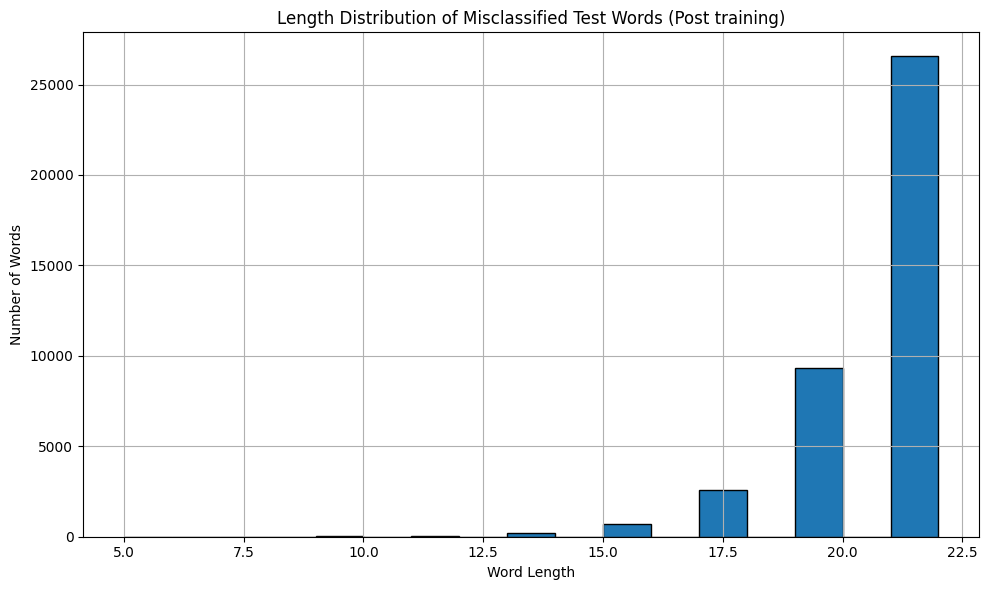

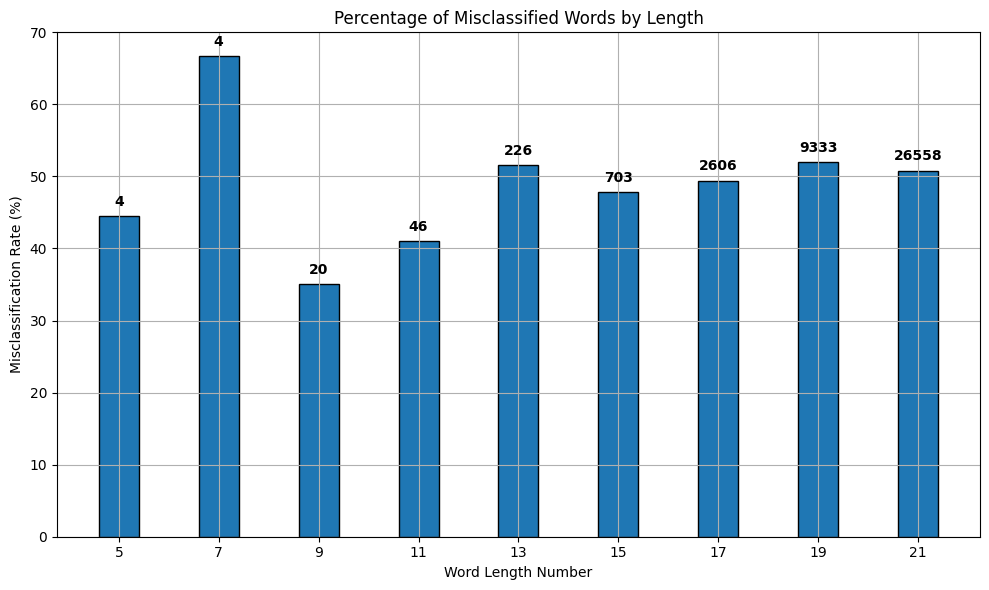

In [ ]:

# Test misclassification
import matplotlib.pyplot as plt
import random
from collections import defaultdict

# Lists to store stats
words = []
wrongs = []
lengths = []
correct_labels = []
dataset_indices = []

# For tracking counts by length
total_by_length = defaultdict(int)
misclassified_by_length = defaultdict(int)

# --- Get ALL predictions given batch of data ---
test_data = test_data.to(device1)
test_labels = test_labels.to(device1)
test_preds = getPredictions(model, test_data)
correct_mask = (test_preds == test_labels)


# --- Fill up the missclasification metric lists ---

for i in range(len(test_preds)):
    input_seq = test_data[i].tolist()
    true_label = test_labels[i].item()
    pred_label = test_preds[i].item()
    
    # Convert to string representation
    word_str = ' '.join([str(int(tok)) for tok in input_seq])
    word_len = sum(1 for ch in word_str.split(" ") if ch != "0" and ch.strip() != "")
    word_len = word_len - 1     # NOTE SUBTRACT SPECIAL TOKEN

    words.append(word_str)
    lengths.append(word_len)
    correct_labels.append(int(test_labels[i]))
    dataset_indices.append(i)
    
    total_by_length[word_len] += 1
    if not correct_mask[i]:
        wrongs.append(1)
        misclassified_by_length[word_len] += 1
    else: 
        wrongs.append(0)

# NOTE: wrongs is like the reverse of correct_mask

# Collect misclassified words
misclassified = [
    (words[i], lengths[i], correct_labels[i], dataset_indices[i])
    for i in range(len(words)) if wrongs[i] > 0
]

# Random sample and print
print("\nRandom Sample of Misclassified Words:")
for word, length, label, idx in random.sample(misclassified, min(20, len(misclassified))):
    print(f"Word: {word} | Length: {length} | Label: {label} | Dataset Index: {idx}")

# Plot 1: Raw misclassified length distribution
misclassified_lengths = [length for _, length, _, _ in misclassified]
plt.figure(figsize=(10, 6))
plt.hist(misclassified_lengths, bins=range(min(misclassified_lengths), max(misclassified_lengths)+2), edgecolor='black')
plt.title("Length Distribution of Misclassified Test Words (Post training)")
plt.xlabel("Word Length")
plt.ylabel("Number of Words")
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Plot 2: Percentage misclassified per length ---

lengths_sorted = sorted(total_by_length.keys())
percent_misclassified = [
    100 * misclassified_by_length[l] / total_by_length[l] for l in lengths_sorted
]
misclassified_counts = [misclassified_by_length[l] for l in lengths_sorted]

plt.figure(figsize=(10, 6))
bars = plt.bar(lengths_sorted, percent_misclassified, edgecolor='black')

# Add bar labels (number of misclassified items)
for bar, count in zip(bars, misclassified_counts):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f'{count}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

# Customize plot appearance
plt.title("Percentage of Misclassified Words by Length")
plt.xlabel("Word Length Number")
plt.ylabel("Misclassification Rate (%)")
plt.xticks(lengths_sorted)  # Ensures ticks align with bar centers
plt.grid(True)
plt.tight_layout()
plt.show()


### Other Misclassification Graphs (IGNORE)
- check on misclassified
- attention heads of random selection of misclassified train inputs

In [ ]:
print(f"total word count: {sum(total_by_length.values())}")
print(f"total misclassified count: {sum(misclassified_by_length.values())}")

total word count: 77585
total misclassified count: 38096


In [ ]:
# =====================================================================
# STRATEGY A: 2D CAUSAL ATTENTION GRAPH FOR A SELECTED WORD
# =====================================================================

# 1. Pick a word index from your train dataset to inspect (e.g., the 0th word)
wordIndex = 0 
chosenWord = train_data[wordIndex].unsqueeze(0).to(device1)  # shape (1, 22)
print("Inspecting word:", chosenWord)

# 2. Generate labels matching the index and generator token (e.g., "0:s_1", "1:s_2")
str_tokens = [f"{i}:s_{tok}" for i, tok in enumerate(chosenWord[0].tolist())]

# 3. Visualize every head over the full 2D sequence grid
n_heads = model.cfg.n_heads
n_layers = model.cfg.n_layers

for layer in range(n_layers):
    for head in range(n_heads):
        # Extract the full 2D matrix shape [22, 22] instead of slicing it
        attn_single_head = cache["pattern", layer][wordIndex, head].detach().cpu()
        
        # Draw the square causal heatmap
        imshow(
            attn_single_head,
            x=str_tokens,       # Horizontal Axis: Keys looked back at
            y=str_tokens,       # Vertical Axis: Current query step
            xaxis="Key (Attended To)",
            yaxis="Query (Paying Attention)",
            title=f"Layer {layer} Head {head} Full Causal Attention Map (A2 Tilda)"
        )

IndexError: index 56923 is out of bounds for dimension 0 with size 51733